In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df_c = pd.read_csv('child.csv')
df_p = pd.read_csv('parent.csv')

In [9]:
len(df_c), len(df_p)

(1001, 1001)

In [10]:
# change the age records with only extract numbers
df_c['user_age'] = df_c['user_age'].str.extract('(\d+)')
df_p['user_age'] = df_p['user_age'].str.extract('(\d+)')

In [11]:
# Convert age keys to integers for correct numeric sorting
age_child = {int(k): v for k, v in df_c['user_age'].value_counts().to_dict().items()}
age_parent = {int(k): v for k, v in df_p['user_age'].value_counts().to_dict().items()}

# Sort by age (numeric)
age_child = dict(sorted(age_child.items()))
age_parent = dict(sorted(age_parent.items()))

# Print age distribution
print("Child Age Distribution:")
total_children = sum(age_child.values())
for age, count in age_child.items():
    print(f"Age {age}: {count} children")
print(f"Total children: {total_children}")

print("\nParent Age Distribution:")
total_parents = sum(age_parent.values())
for age, count in age_parent.items():
    print(f"Age {age}: {count} parents")
print(f"Total parents: {total_parents}")

Child Age Distribution:
Age 2: 11 children
Age 3: 3 children
Age 4: 4 children
Age 5: 12 children
Age 6: 26 children
Age 7: 38 children
Age 8: 56 children
Age 9: 82 children
Age 10: 160 children
Age 11: 136 children
Age 12: 123 children
Age 13: 215 children
Age 14: 67 children
Age 15: 33 children
Age 16: 10 children
Age 17: 8 children
Age 18: 16 children
Total children: 1000

Parent Age Distribution:
Age 1: 1 parents
Age 2: 41 parents
Age 3: 9 parents
Age 4: 24 parents
Age 5: 49 parents
Age 6: 74 parents
Age 7: 87 parents
Age 8: 129 parents
Age 9: 75 parents
Age 10: 123 parents
Age 11: 45 parents
Age 12: 59 parents
Age 13: 70 parents
Age 14: 25 parents
Age 15: 21 parents
Age 16: 28 parents
Age 17: 10 parents
Age 18: 130 parents
Total parents: 1000


/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_66982/2552343309.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


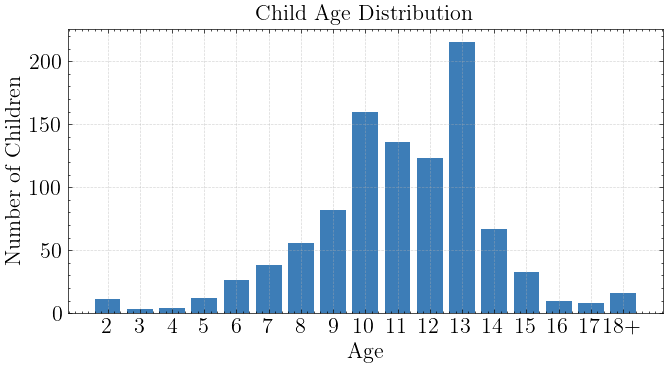

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_66982/2552343309.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


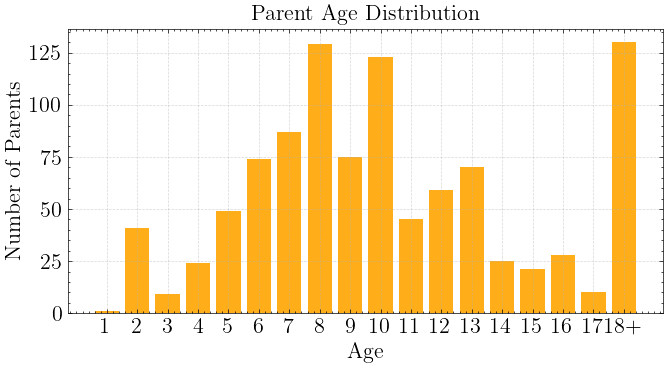

In [12]:
# Convert to pandas Series for plotting
child_series = pd.Series(age_child).sort_index()
parent_series = pd.Series(age_parent).sort_index()

# Rename 18 to '18+' and convert all indices to string for plotting
child_series.index = child_series.index.map(lambda x: '18+' if x == 18 else str(x))
parent_series.index = parent_series.index.map(lambda x: '18+' if x == 18 else str(x))

# Plot child age distribution
plt.figure(figsize=(7, 4))
plt.bar(child_series.index, child_series.values, alpha=0.8)
# plt.plot(child_series.index, child_series.values, marker='o', linestyle='-', label='Child Age Distribution')
plt.title('Child Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Children')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('child_age_distribution.png', dpi=300)
plt.show()

# Plot parent age distribution
plt.figure(figsize=(7, 4))
plt.bar(parent_series.index, parent_series.values, alpha=0.9, color='orange')
# plt.plot(parent_series.index, parent_series.values, marker='o', linestyle='-', label='Parent Age Distribution', color='red')
plt.title('Parent Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Parents')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('parent_age_distribution.png', dpi=300)
plt.show()

In [13]:
age_child.get(2, 0)

11

In [14]:
# Group into different ages: 0-5
age_groups = ["0-5", "6-12", "13-17"]
children_05 = age_child.get(0, 0) + age_child.get(1, 0) + age_child.get(2, 0) + age_child.get(3, 0) + age_child.get(4, 0) + age_child.get(5, 0)
children_612 = age_child.get(6, 0) + age_child.get(7, 0) + age_child.get(8, 0) + age_child.get(9, 0) + age_child.get(10, 0) + age_child.get(11, 0)
children_1317 = age_child.get(12, 0) + age_child.get(13, 0) + age_child.get(14, 0) + age_child.get(15, 0) + age_child.get(16, 0) + age_child.get(17, 0)

parent_05 = age_parent.get(0, 0) + age_parent.get(1, 0) + age_parent.get(2, 0) + age_parent.get(3, 0) + age_parent.get(4, 0) + age_parent.get(5, 0)
parent_612 = age_parent.get(6, 0) + age_parent.get(7, 0) + age_parent.get(8, 0) + age_parent.get(9, 0) + age_parent.get(10, 0) + age_parent.get(11, 0)
parent_1317 = age_parent.get(12, 0) + age_parent.get(13, 0) + age_parent.get(14, 0) + age_parent.get(15, 0) + age_parent.get(16, 0) + age_parent.get(17, 0)

print(f"For children 0-5: {children_05}, 6-12: {children_612}, 13-17: {children_1317}")
print(f"For parents 0-5: {parent_05}, 6-12: {parent_612}, 13-17: {parent_1317}")

For children 0-5: 30, 6-12: 498, 13-17: 456
For parents 0-5: 124, 6-12: 533, 13-17: 213


In [15]:
# A function to find the number of risk codes in a given column

risk_list = ['violence', 'moderation', 'scam', 'bullying', 'dating', 'sexual game', 'explicit', 'purchases', 'strangers', 'hacking', 'horror', 'addiction', 'discrimination',
              'bypass', 'child-generated', 'verify', 'developer']

def find_risk_codes(dataframe):
    # lower case the risk codes
    dataframe['risk code'] = dataframe['risk code'].str.lower()
    num = len(dataframe)
    dict_risk = {} # store the risk codes and their counts
    # check if each risk appears in the 'risk code' column
    for risk in risk_list:
        count = dataframe['risk code'].str.contains(risk).sum()
        dict_risk[risk] = count
    # sort the dictionary by value in descending order
    dict_risk = dict(sorted(dict_risk.items(), key=lambda item: item[1], reverse=True))
    # print the risk codes and their counts
    for risk, count in dict_risk.items():
        print(f"{risk}: {count} ({count/num:.2%})")
    return dict_risk


In [16]:
risk_child = find_risk_codes(df_c)

violence: 282 (28.17%)
bullying: 227 (22.68%)
scam: 203 (20.28%)
dating: 200 (19.98%)
sexual game: 172 (17.18%)
moderation: 150 (14.99%)
explicit: 109 (10.89%)
hacking: 100 (9.99%)
strangers: 78 (7.79%)
horror: 51 (5.09%)
purchases: 40 (4.00%)
bypass: 35 (3.50%)
discrimination: 24 (2.40%)
child-generated: 16 (1.60%)
verify: 4 (0.40%)
addiction: 0 (0.00%)
developer: 0 (0.00%)


In [17]:
risk_parent = find_risk_codes(df_p)

violence: 236 (23.58%)
sexual game: 180 (17.98%)
bullying: 165 (16.48%)
purchases: 138 (13.79%)
moderation: 134 (13.39%)
dating: 130 (12.99%)
scam: 109 (10.89%)
explicit: 89 (8.89%)
strangers: 78 (7.79%)
horror: 64 (6.39%)
addiction: 62 (6.19%)
hacking: 57 (5.69%)
child-generated: 27 (2.70%)
discrimination: 23 (2.30%)
developer: 8 (0.80%)
bypass: 0 (0.00%)
verify: 0 (0.00%)


In [18]:
# Age groups: 0-5 Infant, 6-12 Child, 13-17 Teenager, 18+ Adult
age_groups = {
    '0-5: Infant': (0, 5),
    '6-12: Child': (6, 12),
    '13-17: Teenager': (13, 17),
    '18+: Adult': (18, 100)  # Assuming 100 as a reasonable upper limit for adults
}

In [19]:
# check the top 5 risk codes for each age group
for age_group, (start_age, end_age) in age_groups.items():
    # skip the NaN values in the user_age column
    df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
    df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')

    print("\nFinding risk codes for age group:", age_group)
    child_age_group = df_c[(df_c['user_age'] >= start_age) & (df_c['user_age'] <= end_age)]
    parent_age_group = df_p[(df_p['user_age'] >= start_age) & (df_p['user_age'] <= end_age)]

    print("==========Children Perspective===========")
    find_risk_codes(child_age_group)

    print("\n==========Parents Perspective===========")
    find_risk_codes(parent_age_group)


Finding risk codes for age group: 0-5: Infant
==========Children Perspective===========
violence: 5 (16.67%)
sexual game: 5 (16.67%)
scam: 4 (13.33%)
bullying: 4 (13.33%)
dating: 3 (10.00%)
hacking: 2 (6.67%)
moderation: 1 (3.33%)
explicit: 1 (3.33%)
purchases: 1 (3.33%)
strangers: 1 (3.33%)
horror: 1 (3.33%)
addiction: 0 (0.00%)
discrimination: 0 (0.00%)
bypass: 0 (0.00%)
child-generated: 0 (0.00%)
verify: 0 (0.00%)
developer: 0 (0.00%)

==========Parents Perspective===========
violence: 24 (19.35%)
scam: 16 (12.90%)
bullying: 16 (12.90%)
dating: 15 (12.10%)
moderation: 9 (7.26%)
purchases: 9 (7.26%)
horror: 7 (5.65%)
addiction: 7 (5.65%)
sexual game: 6 (4.84%)
strangers: 5 (4.03%)
explicit: 4 (3.23%)
hacking: 2 (1.61%)
discrimination: 2 (1.61%)
child-generated: 1 (0.81%)
developer: 1 (0.81%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

Finding risk codes for age group: 6-12: Child
==========Children Perspective===========
violence: 175 (28.18%)
scam: 134 (21.58%)
dating: 127 (20.45%)
bullyi

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_66982/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()


In [20]:
# Calculate it for the whole dataset
print("\n==========Overall Risk Codes===========")
df_total = pd.concat([df_c, df_p], ignore_index=True)
# find_risk_codes(df_total)
for age_group, (start_age, end_age) in age_groups.items():
    print(f"\n=========={age_group}===========")
    df_total['user_age'] = pd.to_numeric(df_total['user_age'], errors='coerce')
    age_group_df = df_total[(df_total['user_age'] >= start_age) & (df_total['user_age'] <= end_age)]
    find_risk_codes(age_group_df)   


==========Overall Risk Codes===========

==========0-5: Infant===========
violence: 29 (18.83%)
scam: 20 (12.99%)
bullying: 20 (12.99%)
dating: 18 (11.69%)
sexual game: 11 (7.14%)
moderation: 10 (6.49%)
purchases: 10 (6.49%)
horror: 8 (5.19%)
addiction: 7 (4.55%)
strangers: 6 (3.90%)
explicit: 5 (3.25%)
hacking: 4 (2.60%)
discrimination: 2 (1.30%)
child-generated: 1 (0.65%)
developer: 1 (0.65%)
bypass: 0 (0.00%)
verify: 0 (0.00%)

==========6-12: Child===========
violence: 314 (25.89%)
bullying: 210 (17.31%)
dating: 196 (16.16%)
scam: 192 (15.83%)
sexual game: 181 (14.92%)
moderation: 146 (12.04%)
purchases: 111 (9.15%)
explicit: 89 (7.34%)
hacking: 88 (7.25%)
strangers: 70 (5.77%)
horror: 57 (4.70%)
addiction: 28 (2.31%)
discrimination: 21 (1.73%)
bypass: 20 (1.65%)
child-generated: 14 (1.15%)
developer: 4 (0.33%)
verify: 3 (0.25%)

==========13-17: Teenager===========
violence: 132 (27.10%)
bullying: 129 (26.49%)
sexual game: 111 (22.79%)
moderation: 101 (20.74%)
dating: 90 (18.48%)

/var/folders/6y/npvd4hv14cjcmmgrwl2zt2x40000gn/T/ipykernel_66982/646478024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['risk code'] = dataframe['risk code'].str.lower()


In [21]:
themes = ['Depictions of Physical Violence', 'Leaking/Scamming Personal Information', 'Bullying, Harassment, and Trolling', 'Gaming Becoming Online Dating', 'Encouragement of Unauthorized Purchases', 'Ineffective Game/Community Moderation']
age_groups = ['0-5', '6-12', '13-17']
# Children data (percentages)
children_data = {
    '0-5': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
# Parents data (percentages)
parents_data = {
    '0-5': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

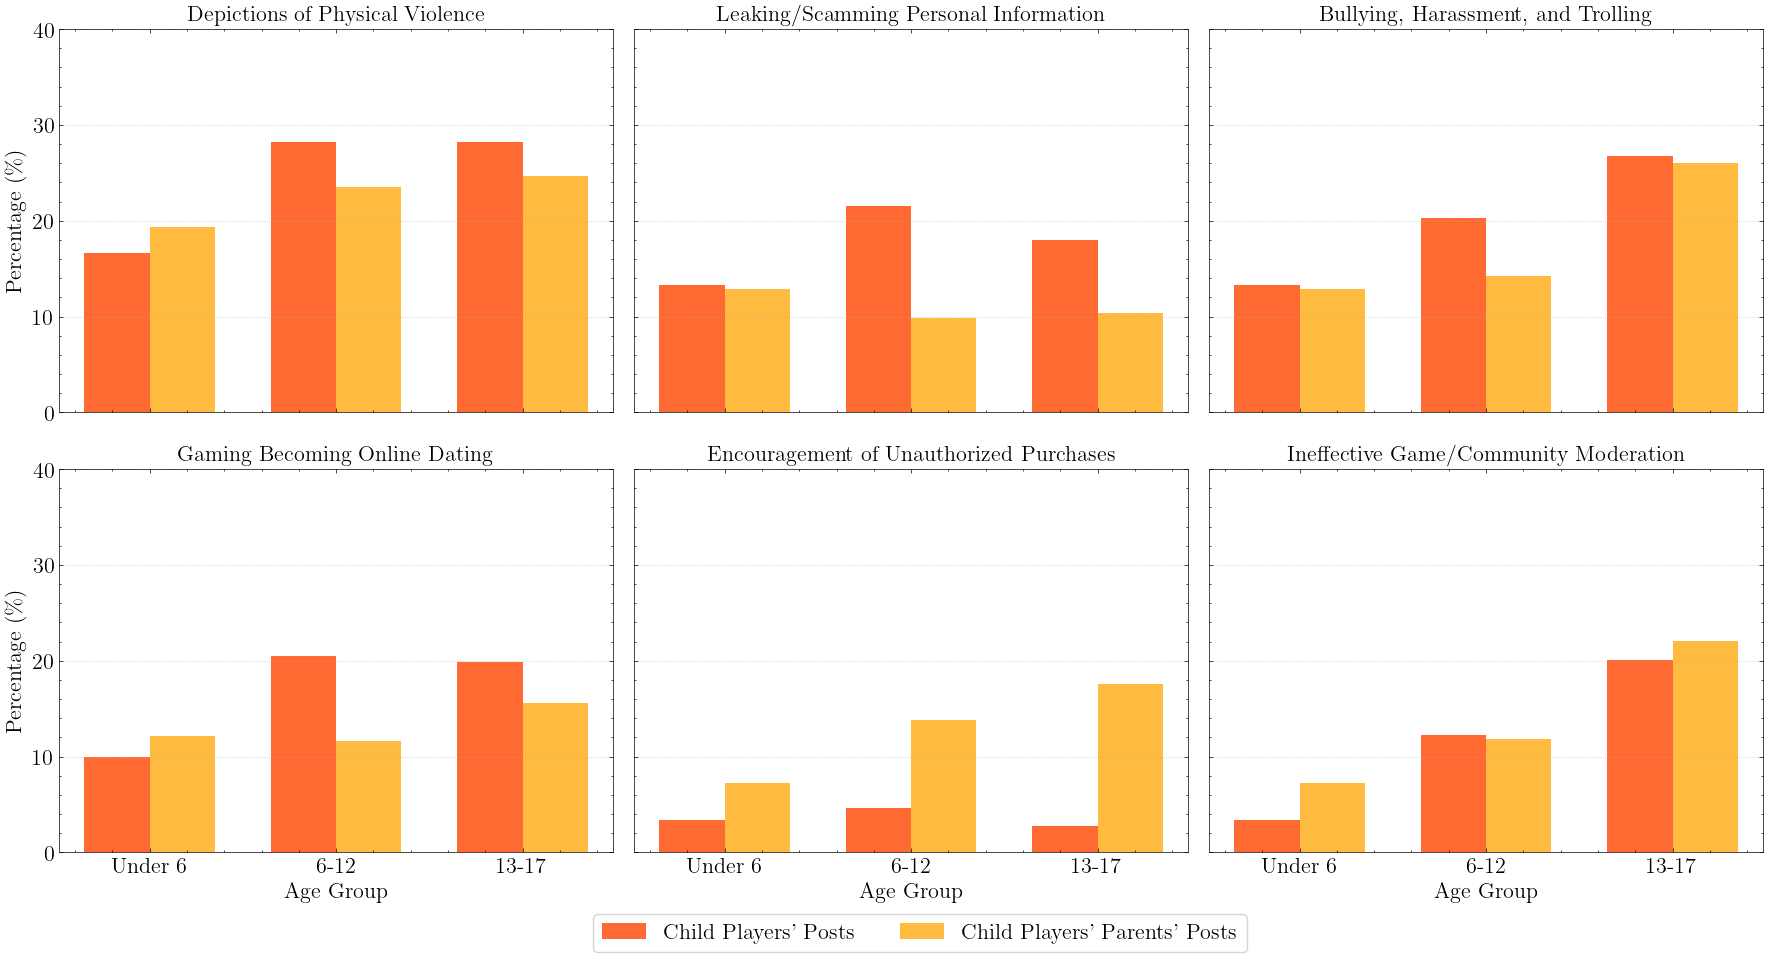

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import scienceplots

plt.style.use('science')

# Set global font sizes (optional but helpful)
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.size': 14
})

# Define y-axis formatter to add %
percent_formatter = FuncFormatter(lambda y, _: f'{y:.0f}%')

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]

age_groups = ['Under 6', '6-12', '13-17']
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}

parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12': [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17': [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

x = np.arange(len(age_groups))
width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

legend_handles = []
legend_labels = []

for i, theme in enumerate(themes):
    ax = axes[i]

    children_vals = [children_data[age][i] for age in age_groups]
    parents_vals = [parents_data[age][i] for age in age_groups]

    child_bars = ax.bar(x - width/2, children_vals, width, label="Child Players’ Posts", color="orangered", alpha=0.8)
    parent_bars = ax.bar(x + width/2, parents_vals, width, label="Child Players’ Parents’ Posts", color="orange", alpha=0.75)

    if i == 0:
        legend_handles = [child_bars[0], parent_bars[0]]
        legend_labels = ['Child Players’ Posts', 'Child Players’ Parents’ Posts']

    ax.set_title(theme)
    ax.set_ylim(0, 40)
    ax.set_yticks(np.arange(0, 41, 10))
    ax.yaxis.set_major_formatter(percent_formatter)
    ax.set_xticks(x)

    if i >= 3:
        ax.set_xticklabels(age_groups)
        ax.set_xlabel('Age Group')
    else:
        ax.set_xticklabels([])

    if i % 3 == 0:
        ax.set_ylabel('Percentage (\%)')
    else:
        ax.set_yticklabels([])

    ax.yaxis.grid(True, linestyle='dotted', alpha=0.8)
    ax.xaxis.grid(False)

# Global legend below all plots
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=2, fontsize=16, frameon=True, bbox_to_anchor=(0.52, 0.02))

# Adjust layout
fig.tight_layout(rect=[0, 0.06, 1, 1])

# Save to PDF
plt.savefig('age_risk_distribution.pdf', dpi=300)
plt.show()


## Statistic Anlaysis

Data:

Comments for children in 0-5: 30, 6-12: 498, 13-17: 456
Comments for parents 0-5: 124, 6-12: 533, 13-17: 213

Distribution:

children_data = {
    'Under 6': [16.67%, 13.33%, 13.33%, 10.00%, 3.33%, 3.33%],

    '6-12': [28.18%, 21.58%, 20.29%, 20.45%, 4.67%, 12.24%],

    '13-17': [28.23%, 18.02%, 26.73%, 19.82%, 2.70%, 20.12%]

}

parents_data = {
    'Under 6': [19.35%, 12.90%, 12.90%, 12.10%, 7.26%, 7.26%],

    '6-12': [23.48%, 9.80%, 14.19%, 11.66%, 13.85%, 11.82%],

    '13-17': [24.68%, 10.39%, 25.97%, 15.58%, 17.53%, 22.08%]

}

## Linear Regression to investigate the relationship between frequncy of age and frequency of risks

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

def calculate_age_risk_regression(dataframe, data_label):
    """
    Calculate linear regression between age and risk frequency.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        DataFrame containing 'user_age' and 'risk code' columns
    data_label : str
        Label for the dataset (e.g., 'Children', 'Parents', 'All')
    
    Returns:
    --------
    dict : Dictionary containing regression results and data
    """
    # Prepare data: Calculate risk frequency per age
    df_work = dataframe.copy()
    df_work['user_age'] = pd.to_numeric(df_work['user_age'], errors='coerce')
    df_work['risk code'] = df_work['risk code'].str.lower()
    
    # For each age, calculate:
    # 1. Age (the actual age value)
    # 2. Risk frequency (total number of risk mentions at that age)
    age_risk_data = []
    
    for age in sorted(df_work['user_age'].dropna().unique()):
        age_df = df_work[df_work['user_age'] == age]
        
        # Count total risk mentions for this age (each row can have multiple risks)
        total_risks = 0
        for risk in risk_list:
            total_risks += age_df['risk code'].str.contains(risk, na=False).sum()
        
        age_risk_data.append({
            'age': int(age),
            'risk_frequency': total_risks
        })
    
    # Convert to DataFrame
    df_age_risk = pd.DataFrame(age_risk_data)
    
    if len(df_age_risk) < 2:
        print(f"\n{data_label}: Insufficient data points for regression (need at least 2)")
        return None
    
    # Prepare data for linear regression
    X = df_age_risk[['age']].values  # Independent variable: age
    y = df_age_risk['risk_frequency'].values   # Dependent variable: risk frequency
    
    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Make predictions
    y_pred = model.predict(X)
    
    # Calculate R² score
    r2 = r2_score(y, y_pred)
    
    # Get regression coefficients
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(X.flatten(), y)[0, 1]
    
    # Print regression results
    print(f"\n{'='*60}")
    print(f"Linear Regression Results for {data_label}")
    print(f"{'='*60}")
    print(f"Equation: Risk Frequency = {intercept:.2f} + {slope:.4f} × Age")
    print(f"R² Score: {r2:.4f}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"Correlation Coefficient: {correlation:.4f}")
    print(f"Number of data points: {len(df_age_risk)}")
    
    # Visualize the relationship
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, alpha=0.6, s=100, label='Data points')
    plt.plot(X, y_pred, color='red', linewidth=2, label=f'Linear Regression (R² = {r2:.4f})')
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Risk Frequency (Total risk mentions at each age)', fontsize=12)
    plt.title(f'Relationship between Age and Risk Frequency - {data_label}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Display the data
    print(f"\nData Summary for {data_label}:")
    print(df_age_risk.to_string(index=False))
    
    return {
        'data': df_age_risk,
        'model': model,
        'r2': r2,
        'slope': slope,
        'intercept': intercept,
        'correlation': correlation,
        'X': X,
        'y': y,
        'y_pred': y_pred
    }


LINEAR REGRESSION ANALYSIS: Age vs Risk Frequency

Linear Regression Results for Children
Equation: Risk Frequency = 39.08 + 6.0392 × Age
R² Score: 0.0738
Slope: 6.0392
Intercept: 39.08
Correlation Coefficient: 0.2717
Number of data points: 17


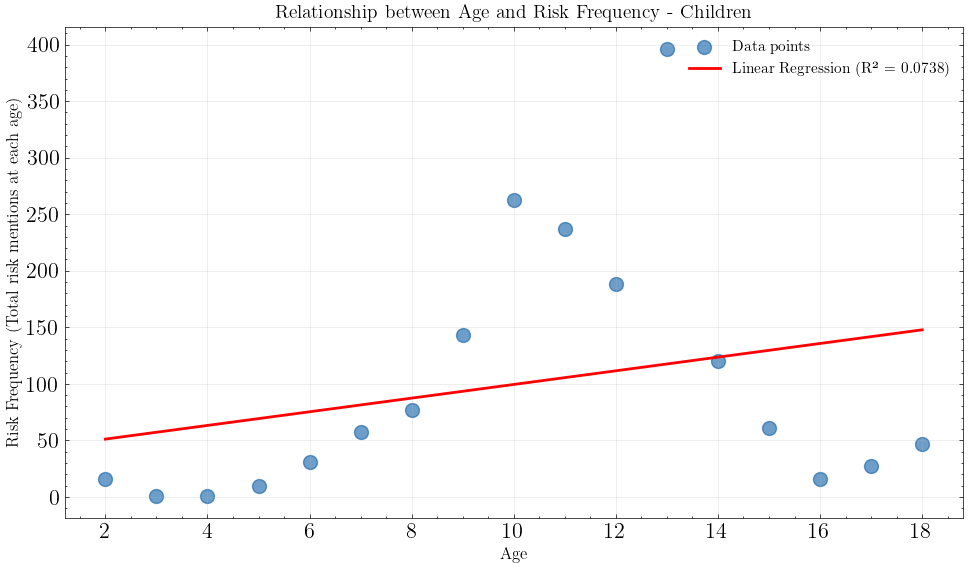


Data Summary for Children:
 age  risk_frequency
   2              16
   3               1
   4               1
   5              10
   6              31
   7              57
   8              77
   9             143
  10             263
  11             237
  12             188
  13             396
  14             120
  15              61
  16              16
  17              27
  18              47


In [24]:
# Call the function for all three datasets
print("="*60)
print("LINEAR REGRESSION ANALYSIS: Age vs Risk Frequency")
print("="*60)

# 1. Children data
df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
df_c['risk code'] = df_c['risk code'].str.lower()
result_children = calculate_age_risk_regression(df_c, "Children")



Linear Regression Results for Parents
Equation: Risk Frequency = 23.33 + 6.3158 × Age
R² Score: 0.2242
Slope: 6.3158
Intercept: 23.33
Correlation Coefficient: 0.4735
Number of data points: 18


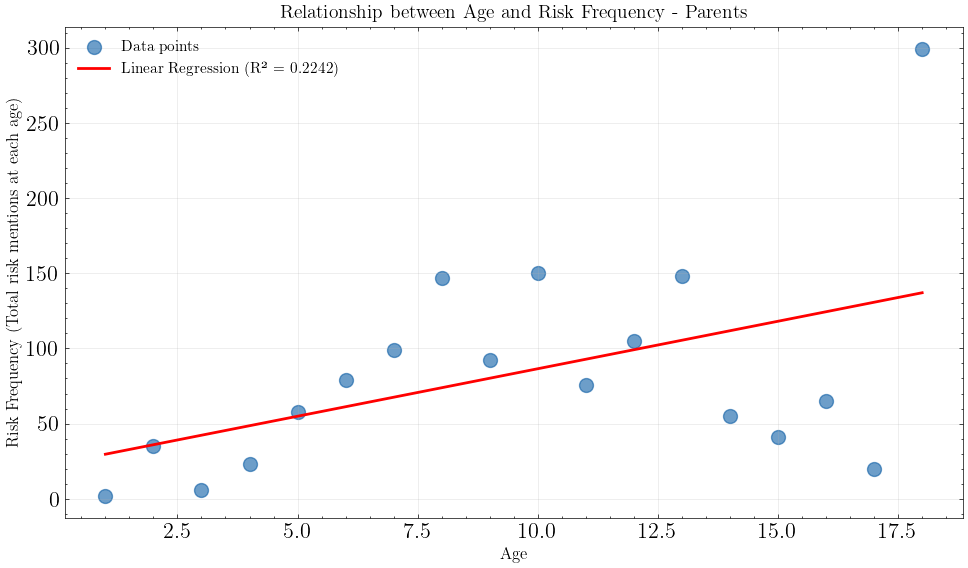


Data Summary for Parents:
 age  risk_frequency
   1               2
   2              35
   3               6
   4              23
   5              58
   6              79
   7              99
   8             147
   9              92
  10             150
  11              76
  12             105
  13             148
  14              55
  15              41
  16              65
  17              20
  18             299


In [25]:
# 2. Parents data
df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')
df_p['risk code'] = df_p['risk code'].str.lower()
result_parents = calculate_age_risk_regression(df_p, "Parents")



Linear Regression Results for All (Children + Parents)
Equation: Risk Frequency = 52.39 + 13.1465 × Age
R² Score: 0.2074
Slope: 13.1465
Intercept: 52.39
Correlation Coefficient: 0.4554
Number of data points: 18


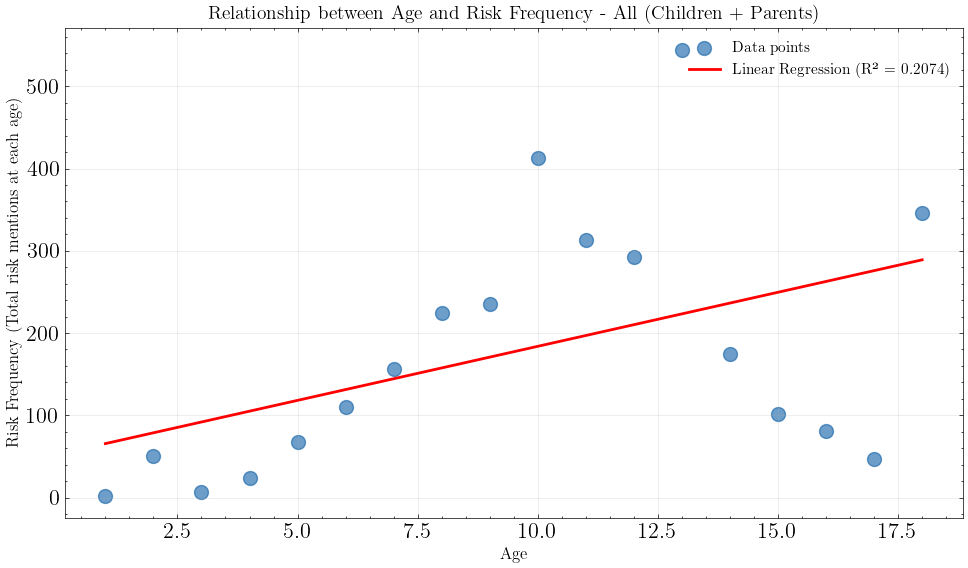


Data Summary for All (Children + Parents):
 age  risk_frequency
   1               2
   2              51
   3               7
   4              24
   5              68
   6             110
   7             156
   8             224
   9             235
  10             413
  11             313
  12             293
  13             544
  14             175
  15             102
  16              81
  17              47
  18             346


In [26]:
# 3. Combined data (all)
df_all = pd.concat([df_c, df_p], ignore_index=True)
result_all = calculate_age_risk_regression(df_all, "All (Children + Parents)")


### Top 6 Risks

LINEAR REGRESSION ANALYSIS: Age vs Risk Frequency (Top 6 Themes Only)
Top 6 themes: violence, scam, bullying, dating, purchases, moderation

Linear Regression Results for Children (Top 6 Themes Only)
Equation: Risk Frequency = 27.35 + 3.7475 × Age
R² Score: 0.0678
Slope: 3.7475
Intercept: 27.35
Correlation Coefficient: 0.2604
Number of data points: 17
Top 6 themes: violence, scam, bullying, dating, purchases, moderation


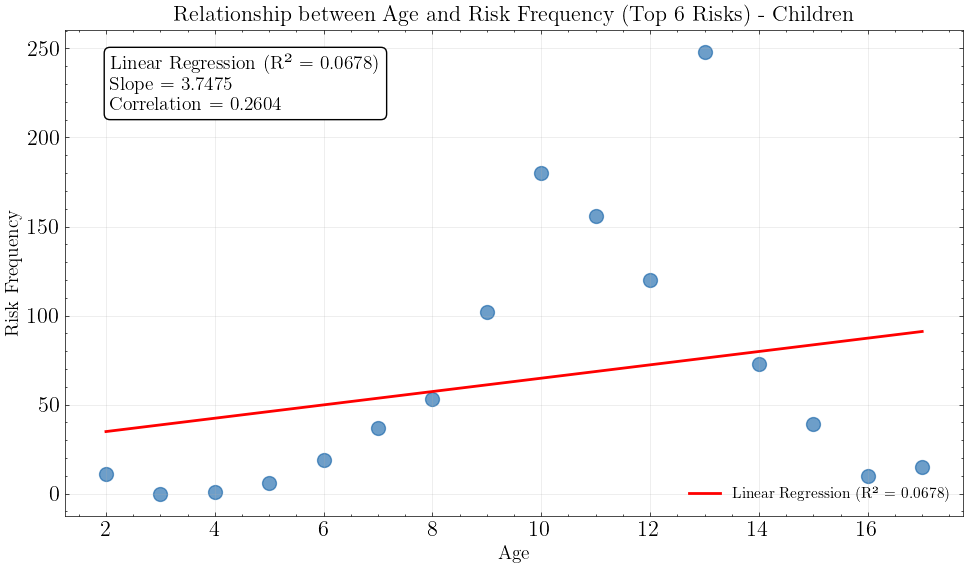


Linear Regression Results for Parents (Top 6 Themes Only)
Equation: Risk Frequency = 24.90 + 2.7121 × Age
R² Score: 0.1448
Slope: 2.7121
Intercept: 24.90
Correlation Coefficient: 0.3805
Number of data points: 18
Top 6 themes: violence, scam, bullying, dating, purchases, moderation


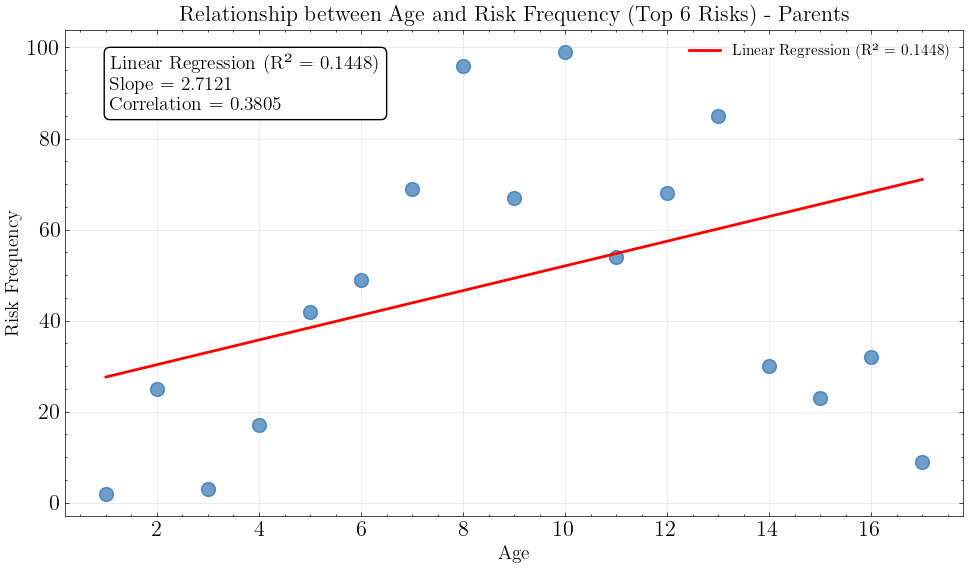


Linear Regression Results for Overall (Top 6 Themes Only)
Equation: Risk Frequency = 45.34 + 7.0052 × Age
R² Score: 0.1482
Slope: 7.0052
Intercept: 45.34
Correlation Coefficient: 0.3849
Number of data points: 18
Top 6 themes: violence, scam, bullying, dating, purchases, moderation


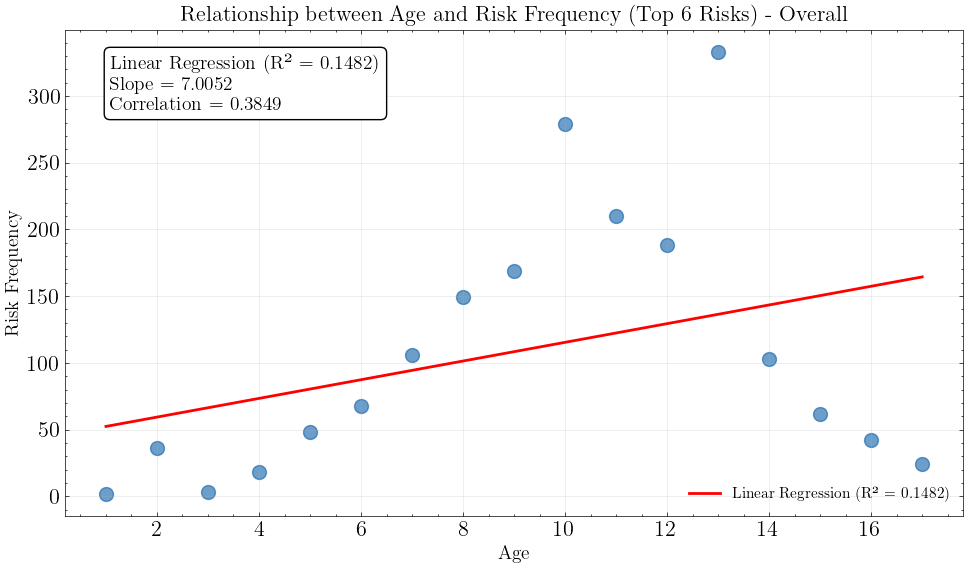

In [27]:
# Linear regression for Top 6 Themes only
import scienceplots

plt.style.use('science')
def calculate_age_risk_regression_top6(dataframe, data_label):
    """
    Calculate linear regression between age and risk frequency.
    Only considers the top 6 themes:
    1. Depictions of Physical Violence (violence)
    2. Leaking/Scamming Personal Information (scam)
    3. Bullying, Harassment, and Trolling (bullying)
    4. Gaming Becoming Online Dating (dating)
    5. Encouragement of Unauthorized Purchases (purchases)
    6. Ineffective Game/Community Moderation (moderation)
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        DataFrame containing 'user_age' and 'risk code' columns
    data_label : str
        Label for the dataset (e.g., 'Children', 'Parents', 'All')
    
    Returns:
    --------
    dict : Dictionary containing regression results and data
    """
    # Top 6 themes mapped to risk codes
    top_6_risks = ['violence', 'scam', 'bullying', 'dating', 'purchases', 'moderation']
    
    # Prepare data: Calculate risk frequency per age
    df_work = dataframe.copy()
    df_work['user_age'] = pd.to_numeric(df_work['user_age'], errors='coerce')
    df_work['risk code'] = df_work['risk code'].str.lower()
    
    # For each age, calculate:
    # 1. Age (the actual age value)
    # 2. Risk frequency (total number of risk mentions at that age - only top 6 themes)
    age_risk_data = []
    
    for age in sorted(df_work['user_age'].dropna().unique()):
        age_df = df_work[df_work['user_age'] == age]
        
        # Count total risk mentions for this age (each row can have multiple risks)
        # Only count the top 6 themes
        total_risks = 0
        for risk in top_6_risks:
            total_risks += age_df['risk code'].str.contains(risk, na=False).sum()
        
        age_risk_data.append({
            'age': int(age),
            'risk_frequency': total_risks
        })
    
    # Convert to DataFrame
    df_age_risk = pd.DataFrame(age_risk_data)
    
    if len(df_age_risk) < 2:
        print(f"\n{data_label}: Insufficient data points for regression (need at least 2)")
        return None
    
    # Prepare data for linear regression
    X = df_age_risk[['age']].values  # Independent variable: age
    y = df_age_risk['risk_frequency'].values   # Dependent variable: risk frequency
    
    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Make predictions
    y_pred = model.predict(X)
    
    # Calculate R² score
    r2 = r2_score(y, y_pred)
    
    # Get regression coefficients
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(X.flatten(), y)[0, 1]
    
    # Print regression results
    print(f"\n{'='*60}")
    print(f"Linear Regression Results for {data_label} (Top 6 Themes Only)")
    print(f"{'='*60}")
    print(f"Equation: Risk Frequency = {intercept:.2f} + {slope:.4f} × Age")
    print(f"R² Score: {r2:.4f}")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"Correlation Coefficient: {correlation:.4f}")
    print(f"Number of data points: {len(df_age_risk)}")
    print(f"Top 6 themes: violence, scam, bullying, dating, purchases, moderation")
    
    # Visualize the relationship
    
    plt.figure(figsize=(10, 6))
    # remove the last point
    plt.scatter(X[:-1], y[:-1], alpha=0.6, s=100)
    plt.plot(X[:-1], y_pred[:-1], color='red', linewidth=2, label=f'Linear Regression (R² = {r2:.4f})')
    plt.xlabel('Age', fontsize=14)
    plt.ylabel('Risk Frequency', fontsize=14)
    plt.title(f'Relationship between Age and Risk Frequency (Top 6 Risks) - {data_label}', fontsize=16)
    
    # Add correlation and slope information as text on the plot
    textstr = f'Linear Regression (R² = {r2:.4f})\nSlope = {slope:.4f}\nCorrelation = {correlation:.4f}'
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{data_label}_top6_age_risk_regression.pdf', dpi=300)
    plt.show()
    
    # Display the data
    # print(f"\nData Summary for {data_label}:")
    # print(df_age_risk.to_string(index=False))
    
    return {
        'data': df_age_risk,
        'model': model,
        'r2': r2,
        'slope': slope,
        'intercept': intercept,
        'correlation': correlation,
        'X': X,
        'y': y,
        'y_pred': y_pred
    }

# Call the function for all three datasets (Top 6 Themes Only)
print("="*60)
print("LINEAR REGRESSION ANALYSIS: Age vs Risk Frequency (Top 6 Themes Only)")
print("="*60)
print("Top 6 themes: violence, scam, bullying, dating, purchases, moderation")
print("="*60)

# 1. Children data
df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
df_c['risk code'] = df_c['risk code'].str.lower()
result_children_top6 = calculate_age_risk_regression_top6(df_c, "Children")

# 2. Parents data
df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')
df_p['risk code'] = df_p['risk code'].str.lower()
result_parents_top6 = calculate_age_risk_regression_top6(df_p, "Parents")

# 3. Combined data (all)
df_all = pd.concat([df_c, df_p], ignore_index=True)
result_all_top6 = calculate_age_risk_regression_top6(df_all, "Overall")


In [28]:
# Rewritten function: Linear regression for each of the Top 6 Risks individually (using age instead of age frequency)
def calculate_age_risk_regression_individual_risks(dataframe, data_label):
    """
    Calculate linear regression between age and risk frequency for each of the top 6 risks individually.
    Only prints R², Slope, and Correlation Coefficient (no plots).
    
    Top 6 risks:
    1. Depictions of Physical Violence (violence)
    2. Leaking/Scamming Personal Information (scam)
    3. Bullying, Harassment, and Trolling (bullying)
    4. Gaming Becoming Online Dating (dating)
    5. Encouragement of Unauthorized Purchases (purchases)
    6. Ineffective Game/Community Moderation (moderation)
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        DataFrame containing 'user_age' and 'risk code' columns
    data_label : str
        Label for the dataset (e.g., 'Children', 'Parents', 'All')
    
    Returns:
    --------
    dict : Dictionary containing regression results for each risk
    """
    # Top 6 themes mapped to risk codes and their full names
    top_6_risks = {
        'violence': 'Depictions of Physical Violence',
        'scam': 'Leaking/Scamming Personal Information',
        'bullying': 'Bullying, Harassment, and Trolling',
        'dating': 'Gaming Becoming Online Dating',
        'purchases': 'Encouragement of Unauthorized Purchases',
        'moderation': 'Ineffective Game/Community Moderation'
    }
    
    # Prepare data
    df_work = dataframe.copy()
    df_work['user_age'] = pd.to_numeric(df_work['user_age'], errors='coerce')
    df_work['risk code'] = df_work['risk code'].str.lower()
    
    # Store results for each risk
    results = {}
    
    print(f"\n{'='*80}")
    print(f"Individual Risk Analysis for {data_label}")
    print(f"{'='*80}")
    print(f"{'Risk':<50} {'R²':<10} {'Slope':<10} {'Correlation':<12}")
    print(f"{'-'*80}")
    
    # Analyze each risk individually
    for risk_code, risk_name in top_6_risks.items():
        # For each age, calculate:
        # 1. Age (the actual age value)
        # 2. Risk frequency (number of mentions of this specific risk at that age)
        age_risk_data = []
        
        for age in sorted(df_work['user_age'].dropna().unique()):
            age_df = df_work[df_work['user_age'] == age]
            
            # Count mentions of this specific risk for this age
            risk_freq = age_df['risk code'].str.contains(risk_code, na=False).sum()
            
            age_risk_data.append({
                'age': int(age),
                'risk_frequency': risk_freq
            })
        
        # Convert to DataFrame
        df_age_risk = pd.DataFrame(age_risk_data)
        
        if len(df_age_risk) < 2:
            print(f"{risk_name:<50} {'N/A':<10} {'N/A':<10} {'N/A':<12}")
            results[risk_code] = None
            continue
        
        # Prepare data for linear regression
        X = df_age_risk[['age']].values  # Independent variable: age
        y = df_age_risk['risk_frequency'].values   # Dependent variable: risk frequency
        
        # Fit linear regression model
        model = LinearRegression()
        model.fit(X, y)
        
        # Make predictions
        y_pred = model.predict(X)
        
        # Calculate R² score
        r2 = r2_score(y, y_pred)
        
        # Get regression coefficients
        slope = model.coef_[0]
        intercept = model.intercept_
        
        # Calculate correlation coefficient
        correlation = np.corrcoef(X.flatten(), y)[0, 1]
        
        # Print results
        print(f"{risk_name:<50} {r2:<10.4f} {slope:<10.4f} {correlation:<12.4f}")
        
        # Store results
        results[risk_code] = {
            'risk_name': risk_name,
            'data': df_age_risk,
            'model': model,
            'r2': r2,
            'slope': slope,
            'intercept': intercept,
            'correlation': correlation,
            'X': X,
            'y': y,
            'y_pred': y_pred
        }
    
    print(f"{'='*80}\n")
    
    return results

# Call the function for all three datasets
print("="*80)
print("INDIVIDUAL RISK ANALYSIS: Age vs Risk Frequency (Top 6 Risks)")
print("="*80)

# 1. Children data
df_c['user_age'] = pd.to_numeric(df_c['user_age'], errors='coerce')
df_c['risk code'] = df_c['risk code'].str.lower()
results_children_individual = calculate_age_risk_regression_individual_risks(df_c, "Children")

# 2. Parents data
df_p['user_age'] = pd.to_numeric(df_p['user_age'], errors='coerce')
df_p['risk code'] = df_p['risk code'].str.lower()
results_parents_individual = calculate_age_risk_regression_individual_risks(df_p, "Parents")

# 3. Combined data (all)
df_all = pd.concat([df_c, df_p], ignore_index=True)
results_all_individual = calculate_age_risk_regression_individual_risks(df_all, "All (Children + Parents)")


INDIVIDUAL RISK ANALYSIS: Age vs Risk Frequency (Top 6 Risks)

Individual Risk Analysis for Children
Risk                                               R²         Slope      Correlation 
--------------------------------------------------------------------------------
Depictions of Physical Violence                    0.0374     0.7574     0.1933      
Leaking/Scamming Personal Information              0.0596     0.6471     0.2442      
Bullying, Harassment, and Trolling                 0.0863     0.8799     0.2937      
Gaming Becoming Online Dating                      0.0561     0.6471     0.2368      
Encouragement of Unauthorized Purchases            0.0171     0.0760     0.1307      
Ineffective Game/Community Moderation              0.1345     0.7402     0.3667      


Individual Risk Analysis for Parents
Risk                                               R²         Slope      Correlation 
--------------------------------------------------------------------------------
Depictions

## Risk category-based significance checking

For each of the six risk category: 

(1) are there any significant differences between parents’ perspectives across age groups?

(2) are there any significant differences between children’s perspectives across age groups?

(3) are there any significant differences between user perspectives overall (children and parents combined) across age groups?

(4) are there any significant differences between children’s perspective and parents’ perspective in the same age group?


1. For the parents

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# -------------------------
# 1) Input data
# -------------------------
themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]
age_groups = ['Under 6', '6-12', '13-17']

parent_totals = {'Under 6': 124, '6-12': 533, '13-17': 213}

parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12':    [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17':   [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

# -------------------------
# 2) Helper function: convert % -> integer counts
# -------------------------
def pct_to_count(percent, total):
    return int(round(percent / 100.0 * total))

# -------------------------
# 3) Helper function: calculate Cramér's V
# -------------------------
def cramers_v(chi2, n, rows, cols):
    """
    Calculate Cramér's V effect size for chi-square test.
    
    Parameters:
    - chi2: Chi-square statistic
    - n: Total sample size
    - rows: Number of rows in contingency table
    - cols: Number of columns in contingency table
    
    Returns:
    - Cramér's V value
    """
    k = min(rows - 1, cols - 1)
    return np.sqrt(chi2 / (n * k))

def interpret_cramers_v(v, df):
    """
    Interpret Cramér's V based on degrees of freedom.
    
    Parameters:
    - v: Cramér's V value
    - df: Degrees of freedom (min(rows-1, cols-1))
    
    Returns:
    - Interpretation string
    """
    if df == 1:
        if v < 0.10:
            return "negligible"
        elif v < 0.30:
            return "small"
        elif v < 0.50:
            return "medium"
        else:
            return "large"
    elif df == 2:
        if v < 0.07:
            return "negligible"
        elif v < 0.21:
            return "small"
        elif v < 0.35:
            return "medium"
        else:
            return "large"
    else:  # df >= 3
        if v < 0.06:
            return "negligible"
        elif v < 0.17:
            return "small"
        elif v < 0.29:
            return "medium"
        else:
            return "large"

# -------------------------
# 4) Build counts and run chi-square per risk
# -------------------------
rows = []
total_n = sum(parent_totals.values())

for i, theme in enumerate(themes):
    counts = []
    for age in age_groups:
        count = pct_to_count(parents_data[age][i], parent_totals[age])
        counts.append(count)
    
    # Construct contingency table: rows = age groups, cols = [mentions, non-mentions]
    table = np.array([
        [counts[0], parent_totals['Under 6'] - counts[0]],
        [counts[1], parent_totals['6-12'] - counts[1]],
        [counts[2], parent_totals['13-17'] - counts[2]]
    ])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    # Calculate Cramér's V
    n_rows, n_cols = table.shape
    cramers = cramers_v(chi2, total_n, n_rows, n_cols)
    
    # Interpret effect size
    df_effect = min(n_rows - 1, n_cols - 1)
    interpretation = interpret_cramers_v(cramers, df_effect)
    
    rows.append({
        "Risk": theme,
        "Counts (Under 6)": f"{table[0,0]}/{parent_totals['Under 6']}",
        "Counts (6-12)":    f"{table[1,0]}/{parent_totals['6-12']}",
        "Counts (13-17)":   f"{table[2,0]}/{parent_totals['13-17']}",
        "Chi2": chi2,
        "p-value": p,
        "Cramér's V": cramers,
        "Effect Size": interpretation
    })

results_df_parent = pd.DataFrame(rows)

# Display results with formatting
print(results_df_parent.to_string(index=False))

# Optional: Format for LaTeX table
print("\n" + "="*80)
print("Formatted for reporting:")
print("="*80)
for _, row in results_df_parent.iterrows():
    print(f"{row['Risk']}: χ²={row['Chi2']:.2f}, p={row['p-value']:.4f}, V={row['Cramér\'s V']:.3f} ({row['Effect Size']})")


SyntaxError: f-string expression part cannot include a backslash (1259947578.py, line 140)

In [ ]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# store the numbers in a dataframe
df_stat = []
for i, theme in enumerate(themes):
    for age in age_groups:
        df_stat.append({"Risk": theme, "Age": age, "Group": "Parents", "Value": parents_data[age][i]})
        df_stat.append({"Risk": theme, "Age": age, "Group": "Children", "Value": children_data[age][i]})
df_stat = pd.DataFrame(df_stat)


2. For each risk, are there any significant differences between children's perspectives across age groups?

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

# -------------------------
# Helper functions for effect size
# -------------------------
def cramers_v(chi2, n, rows, cols):
    """
    Calculate Cramér's V effect size for chi-square test.
    
    Parameters:
    - chi2: Chi-square statistic
    - n: Total sample size
    - rows: Number of rows in contingency table
    - cols: Number of columns in contingency table
    
    Returns:
    - Cramér's V value
    """
    k = min(rows - 1, cols - 1)
    return np.sqrt(chi2 / (n * k))

def interpret_cramers_v(v, df):
    """
    Interpret Cramér's V based on degrees of freedom.
    
    Parameters:
    - v: Cramér's V value
    - df: Degrees of freedom (min(rows-1, cols-1))
    
    Returns:
    - Interpretation string
    """
    if df == 1:
        if v < 0.10:
            return "negligible"
        elif v < 0.30:
            return "small"
        elif v < 0.50:
            return "medium"
        else:
            return "large"
    elif df == 2:
        if v < 0.07:
            return "negligible"
        elif v < 0.21:
            return "small"
        elif v < 0.35:
            return "medium"
        else:
            return "large"
    else:  # df >= 3
        if v < 0.06:
            return "negligible"
        elif v < 0.17:
            return "small"
        elif v < 0.29:
            return "medium"
        else:
            return "large"

# -------------------------
# Children data
# -------------------------
children_counts = {'Under 6': 30, '6-12': 498, '13-17': 456}

# Children distribution percentages
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12': [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17': [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]

# Calculate total sample size
total_n = sum(children_counts.values())

results = {}

for i, theme in enumerate(themes):
    # Build contingency table for this theme
    table = []
    for group, n in children_counts.items():
        mentions = round(n * children_data[group][i] / 100)
        non_mentions = n - mentions
        table.append([mentions, non_mentions])
    
    table = np.array(table)
    chi2, p, dof, exp = chi2_contingency(table)
    
    # Calculate Cramér's V
    n_rows, n_cols = table.shape
    cramers = cramers_v(chi2, total_n, n_rows, n_cols)
    
    # Interpret effect size
    df_effect = min(n_rows - 1, n_cols - 1)
    interpretation = interpret_cramers_v(cramers, df_effect)
    
    results[theme] = {
        'chi2': chi2,
        'p': p,
        'dof': dof,
        'cramers_v': cramers,
        'effect_size': interpretation,
        'table': table
    }

# -------------------------
# Display results
# -------------------------
print("Children's Reviews - Chi-Square Test Results with Effect Sizes")
print("=" * 100)
print(f"{'Risk Theme':<50} {'χ²':<8} {'df':<4} {'p-value':<10} {'V':<8} {'Effect':<12}")
print("=" * 100)

for theme, stats in results.items():
    print(f"{theme:<50} {stats['chi2']:>7.2f} {stats['dof']:>3} {stats['p']:>9.4f} {stats['cramers_v']:>7.3f} {stats['effect_size']:<12}")

print("\n" + "=" * 100)
print("Formatted for LaTeX reporting:")
print("=" * 100)

for theme, stats in results.items():
    # Format p-value in scientific notation if very small
    if stats['p'] < 0.001:
        p_str = f"p < .001"
    else:
        p_str = f"p = {stats['p']:.3f}"
    
    print(f"{theme}:")
    print(f"  χ²({stats['dof']}, N={total_n}) = {stats['chi2']:.2f}, {p_str}, Cramér's V = {stats['cramers_v']:.3f} ({stats['effect_size']})")
    print()

Children's Reviews - Chi-Square Test Results with Effect Sizes
Risk Theme                                         χ²       df   p-value    V        Effect      
Depictions of Physical Violence                       1.93   2    0.3813   0.044 negligible  
Leaking/Scamming Personal Information                 2.63   2    0.2688   0.052 negligible  
Bullying, Harassment, and Trolling                    7.27   2    0.0263   0.086 negligible  
Gaming Becoming Online Dating                         1.96   2    0.3753   0.045 negligible  
Encouragement of Unauthorized Purchases               2.68   2    0.2625   0.052 negligible  
Ineffective Game/Community Moderation                14.89   2    0.0006   0.123 small       

Formatted for LaTeX reporting:
Depictions of Physical Violence:
  χ²(2, N=984) = 1.93, p = 0.381, Cramér's V = 0.044 (negligible)

Leaking/Scamming Personal Information:
  χ²(2, N=984) = 2.63, p = 0.269, Cramér's V = 0.052 (negligible)

Bullying, Harassment, and Trolling:
 

3. For each risk, are there significant differences between user perspectives overall (children + parents combined) across age groups?

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

children_totals = {'Under 6': 30, '6-12': 498, '13-17': 456}
parent_totals   = {'Under 6': 124, '6-12': 533, '13-17': 213}
# Calculate total sample size (all reviews combined)
total_n = sum(children_totals.values()) + sum(parent_totals.values())

# -------------------------
# convert % -> integer counts
# -------------------------
def pct_to_count(percent, total):
    # Round to nearest integer; clamp within [0, total] just in case
    c = int(round(percent / 100.0 * total))
    return min(max(c, 0), total)

# -------------------------
# Build combined counts and run chi-square per risk
# -------------------------
rows = []
for i, theme in enumerate(themes):
    # Combine children + parents counts for each age group
    combined_mentions = []
    combined_nonmentions = []
    for age in age_groups:
        child_m = pct_to_count(children_data[age][i], children_totals[age])
        par_m   = pct_to_count(parents_data[age][i],  parent_totals[age])
        mentions = child_m + par_m
        total_age = children_totals[age] + parent_totals[age]
        nonmentions = total_age - mentions

        combined_mentions.append(mentions)
        combined_nonmentions.append(nonmentions)

    # 3x2 contingency: rows=ages, cols=[mentions, nonmentions]
    table = np.array([
        [combined_mentions[0], combined_nonmentions[0]],  # Under 6
        [combined_mentions[1], combined_nonmentions[1]],  # 6-12
        [combined_mentions[2], combined_nonmentions[2]],  # 13-17
    ])

    chi2, p, dof, expected = chi2_contingency(table)  # no Yates correction for >2x2

    # Calculate Cramér's V
    n_rows, n_cols = table.shape
    cramers = cramers_v(chi2, total_n, n_rows, n_cols)
    
    # Interpret effect size
    df_effect = min(n_rows - 1, n_cols - 1)
    interpretation = interpret_cramers_v(cramers, df_effect)

    # Save result + readable counts
    rows.append({
        "Risk": theme,
        "Chi2": chi2,
        "p-value": p,
        "DoF": dof,
        "Cramér's V": cramers,
        "Effect Size": interpretation,
        "Counts (Under 6)": f"{table[0,0]} mentions / {table[0,1]} non",
        "Counts (6-12)":    f"{table[1,0]} mentions / {table[1,1]} non",
        "Counts (13-17)":   f"{table[2,0]} mentions / {table[2,1]} non",
    })

results_df = pd.DataFrame(rows).sort_values("p-value")

def sig(star_p):
    if star_p < 0.001: return "***"
    if star_p < 0.01:  return "**"
    if star_p < 0.05:  return "*"
    return ""

results_df["Signif"] = results_df["p-value"].apply(sig)

# Display results
print(results_df.to_string(index=False))

# -------------------------
# Optional: Formatted output for reporting
# -------------------------
print("\n" + "=" * 100)
print("Formatted for LaTeX reporting:")
print("=" * 100)

for _, row in results_df.iterrows():
    # Format p-value
    if row['p-value'] < 0.001:
        p_str = "p < .001"
    else:
        p_str = f"p = {row['p-value']:.3f}"
    
    print(f"{row['Risk']}:")
    print(f"  χ²({row['DoF']}, N={total_n}) = {row['Chi2']:.2f}, {p_str}, "
          f"Cramér's V = {row['Cramér\'s V']:.3f} ({row['Effect Size']}){row['Signif']}")
    print()

                                   Risk      Chi2      p-value  DoF  Cramér's V Effect Size      Counts (Under 6)          Counts (6-12)         Counts (13-17) Signif
  Ineffective Game/Community Moderation 33.802039 4.570677e-08    2    0.135026       small 10 mentions / 144 non 124 mentions / 907 non 139 mentions / 530 non    ***
     Bullying, Harassment, and Trolling 27.127912 1.286023e-06    2    0.120963       small 20 mentions / 134 non 177 mentions / 854 non 177 mentions / 492 non    ***
        Depictions of Physical Violence  4.600793 1.002191e-01    2    0.049815  negligible 29 mentions / 125 non 265 mentions / 766 non 182 mentions / 487 non       
          Gaming Becoming Online Dating  4.585390 1.009939e-01    2    0.049732  negligible 18 mentions / 136 non 164 mentions / 867 non 123 mentions / 546 non       
Encouragement of Unauthorized Purchases  3.090571 2.132510e-01    2    0.040829  negligible 10 mentions / 144 non  97 mentions / 934 non  49 mentions / 620 non      

4. For each risk, are there any significant differences between children’s perspective and parents’ perspective in the same age group?

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Total comments
children_totals = {"Under 6": 30, "6-12": 498, "13-17": 456}
parent_totals   = {"Under 6": 124, "6-12": 533, "13-17": 213}

# Percentages
children_data = {
    'Under 6': [16.67, 13.33, 13.33, 10.00, 3.33, 3.33],
    '6-12':    [28.18, 21.58, 20.29, 20.45, 4.67, 12.24],
    '13-17':   [28.23, 18.02, 26.73, 19.82, 2.70, 20.12]
}
parents_data = {
    'Under 6': [19.35, 12.90, 12.90, 12.10, 7.26, 7.26],
    '6-12':    [23.48, 9.80, 14.19, 11.66, 13.85, 11.82],
    '13-17':   [24.68, 10.39, 25.97, 15.58, 17.53, 22.08]
}

themes = [
    'Depictions of Physical Violence',
    'Leaking/Scamming Personal Information',
    'Bullying, Harassment, and Trolling',
    'Gaming Becoming Online Dating',
    'Encouragement of Unauthorized Purchases',
    'Ineffective Game/Community Moderation'
]

results = []

for age in ["Under 6", "6-12", "13-17"]:
    for i, theme in enumerate(themes):
        # Convert percentages → counts
        child_mentions = round(children_data[age][i] / 100 * children_totals[age])
        parent_mentions = round(parents_data[age][i] / 100 * parent_totals[age])
        
        child_non = children_totals[age] - child_mentions
        parent_non = parent_totals[age] - parent_mentions
        
        # 2×2 table
        table = np.array([[child_mentions, child_non],
                          [parent_mentions, parent_non]])
        
        chi2, p, dof, _ = chi2_contingency(table)
        
        # Calculate total N for this age group
        total_n = children_totals[age] + parent_totals[age]
        
        # Calculate Cramér's V (for 2×2 table, this equals phi)
        n_rows, n_cols = table.shape
        cramers = cramers_v(chi2, total_n, n_rows, n_cols)
        
        # Interpret effect size (df=1 for 2×2 table)
        df_effect = min(n_rows - 1, n_cols - 1)
        interpretation = interpret_cramers_v(cramers, df_effect)
        
        results.append({
            "Age": age,
            "Risk": theme,
            "Child %": children_data[age][i],
            "Parent %": parents_data[age][i],
            "Chi2": round(chi2, 2),
            "p-value": round(p, 4),
            "Cramers_V": round(cramers, 3),
            "Effect_Size": interpretation
        })

results_df = pd.DataFrame(results)

# Display results
print(results_df.to_string(index=False))

# -------------------------
# Optional: Show significant results only
# -------------------------
print("\n" + "=" * 100)
print("Significant Results (p < 0.05):")
print("=" * 100)

sig_results = results_df[results_df['p-value'] < 0.05].sort_values('p-value')
if len(sig_results) > 0:
    print(sig_results.to_string(index=False))
else:
    print("No significant differences found.")

# -------------------------
# Optional: Formatted output for reporting
# -------------------------
print("\n" + "=" * 100)
print("Formatted for LaTeX reporting (significant results only):")
print("=" * 100)

for _, row in sig_results.iterrows():
    if row['p-value'] < 0.001:
        p_str = "p < .001"
    else:
        p_str = f"p = {row['p-value']:.3f}"
    
    n_total = children_totals[row['Age']] + parent_totals[row['Age']]
    
    print(f"{row['Age']} - {row['Risk']}:")
    print(f"  Children: {row['Child %']:.1f}%, Parents: {row['Parent %']:.1f}%")
    print(f"  χ²(1, N={n_total}) = {row['Chi2']:.2f}, {p_str}, "
          f"Cramér's V = {row['Cramers_V']:.3f} ({row['Effect_Size']})")
    print()

    Age                                    Risk  Child %  Parent %  Chi2  p-value  Cramers_V Effect_Size
Under 6         Depictions of Physical Violence    16.67     19.35  0.01   0.9380      0.006  negligible
Under 6   Leaking/Scamming Personal Information    13.33     12.90  0.00   1.0000      0.000  negligible
Under 6      Bullying, Harassment, and Trolling    13.33     12.90  0.00   1.0000      0.000  negligible
Under 6           Gaming Becoming Online Dating    10.00     12.10  0.00   0.9967      0.000  negligible
Under 6 Encouragement of Unauthorized Purchases     3.33      7.26  0.14   0.7114      0.030  negligible
Under 6   Ineffective Game/Community Moderation     3.33      7.26  0.14   0.7114      0.030  negligible
   6-12         Depictions of Physical Violence    28.18     23.48  2.69   0.1010      0.051  negligible
   6-12   Leaking/Scamming Personal Information    21.58      9.80 26.27   0.0000      0.160       small
   6-12      Bullying, Harassment, and Trolling    20.2